# **Predicción de géneros musicales con métricas de Spotify**

### Iñaki Irarrazaval - Lisandro Russo - Manuel Ferrario

## Objetivo del trabajo

El objetivo es resolver un problema de clasificación multiclase: predecir el género musical de una canción a partir de sus características acústicas y métricas disponibles en el dataset de Spotify.

La variable objetivo es `Expected`, que contiene seis géneros: `acoustic`, `classical`, `electronic`, `hip-hop`, `jazz` y `rock`. La columna `Id` identifica cada registro y no debería utilizarse como predictor, porque funciona como identificador y podría introducir patrones espurios.

Además de buscar un buen resultado en la competencia de Kaggle, el análisis debe permitir entender qué características diferencian a los géneros, qué transformaciones necesitan los datos y qué modelo ofrece el mejor equilibrio entre desempeño e interpretabilidad.

## Restricciones

- Trabajar únicamente con `train.csv` y `test.csv` provistos para el trabajo.
- No utilizar APIs externas ni cruzar los datos con el dataset original para recuperar etiquetas.
- Separar correctamente las variables predictoras (`X`) de la variable objetivo (`y`).
- Evitar fuga de información: todo ajuste de transformaciones debe hacerse utilizando únicamente los datos de entrenamiento.


## 1. Carga y revisión inicial de los datos

Cargar `train.csv` y `test.csv` desde la carpeta de datos. Revisar las dimensiones de ambos conjuntos, los tipos de datos, los nombres de las columnas y algunos registros de ejemplo.

También verificar valores faltantes, filas duplicadas y cardinalidad de la variable objetivo. Comparar las columnas de entrenamiento y prueba para confirmar que `Expected` está presente únicamente en entrenamiento y que `Id` es un identificador.

**Pregunta que buscamos responder:** ¿Con qué datos contamos, qué problemas de calidad existen y qué columnas pueden utilizarse legítimamente para predecir el género?


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [39]:
print(train.dtypes)

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected                str
Id                    int64
dtype: object


In [40]:
for feature in train.columns:
    print(f"{feature}: {train[feature].isnull().sum()} valores NaN")

popularity: 0 valores NaN
duration_ms: 0 valores NaN
explicit: 0 valores NaN
danceability: 0 valores NaN
energy: 0 valores NaN
key: 0 valores NaN
loudness: 0 valores NaN
mode: 0 valores NaN
speechiness: 0 valores NaN
acousticness: 0 valores NaN
instrumentalness: 0 valores NaN
liveness: 0 valores NaN
valence: 0 valores NaN
tempo: 0 valores NaN
time_signature: 0 valores NaN
Expected: 0 valores NaN
Id: 0 valores NaN


In [41]:
print(test.dtypes)

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Id                    int64
dtype: object


In [42]:
for feature in test.columns:
    print(f"{feature}: {test[feature].isnull().sum()} valores NaN")

popularity: 0 valores NaN
duration_ms: 0 valores NaN
explicit: 0 valores NaN
danceability: 0 valores NaN
energy: 0 valores NaN
key: 0 valores NaN
loudness: 0 valores NaN
mode: 0 valores NaN
speechiness: 0 valores NaN
acousticness: 0 valores NaN
instrumentalness: 0 valores NaN
liveness: 0 valores NaN
valence: 0 valores NaN
tempo: 0 valores NaN
time_signature: 0 valores NaN
Id: 0 valores NaN


> Analizando los datasets de train y test vemos que no hay valores NaN. En los dataset vamos a eliminar la columna de ID para no sesgar el modelo, ya que no tiene peso en la prediccion. 

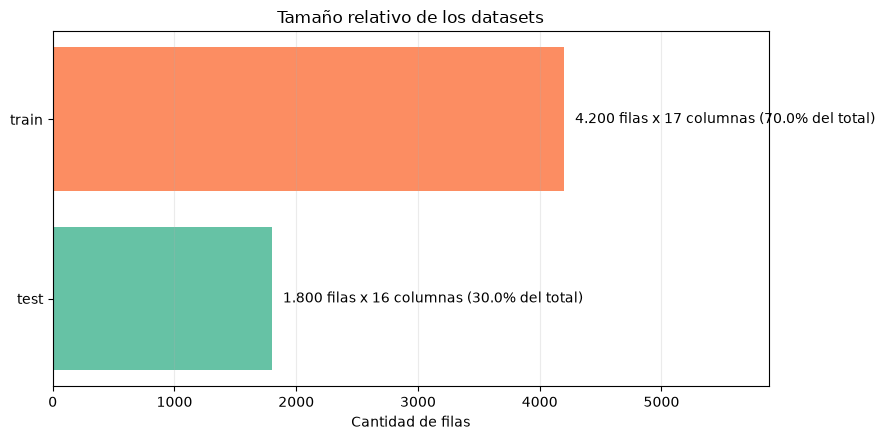

In [43]:
sizes = pd.DataFrame({
    "Dataset": ["train", "test"],
    "Filas": [len(train), len(test)],
    "Columnas": [train.shape[1], test.shape[1]],
}).sort_values("Filas", ascending=True)

sizes["Etiqueta"] = sizes.apply(
    lambda row: f"{int(row['Filas']):,} filas x {int(row['Columnas'])} columnas".replace(",", "."),
    axis=1,
)
total_filas = sizes["Filas"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(sizes["Dataset"], sizes["Filas"], color=["#66c2a5", "#fc8d62"])

for bar, (_, row) in zip(bars, sizes.iterrows()):
    ax.text(
        bar.get_width() + total_filas * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Etiqueta']} ({row['Filas'] / total_filas:.1%} del total)",
        va="center",
    )

ax.set_title("Tamaño relativo de los datasets")
ax.set_xlabel("Cantidad de filas")
ax.set_ylabel("")
ax.set_xlim(0, sizes["Filas"].max() * 1.4)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


> Los datos estan separados en un 70% de train y un 30% de test. Seguimos con mas analisis de datos.

## 2. Análisis Exploratorio de Datos (EDA)

Analizar cómo se distribuyen las variables numéricas y cómo se relacionan con `Expected`. Incluir al menos tres visualizaciones relevantes, por ejemplo:

1. Distribución de géneros mediante un gráfico de barras para detectar desbalance de clases.
2. Boxplots o violin plots de variables como `danceability`, `energy`, `acousticness`, `instrumentalness`, `valence` y `tempo`, separados por género.
3. Matriz de correlación entre las variables numéricas para detectar redundancia y relaciones fuertes.

También se pueden incluir histogramas, gráficos de densidad o proyecciones bidimensionales para complementar el análisis.

**Pregunta que buscamos responder:** ¿Qué características parecen diferenciar mejor a los géneros y cuáles presentan distribuciones similares entre clases?

In [44]:
print("Duplicados en train:", train.duplicated().sum())
print("Duplicados en test:", test.duplicated().sum())

train["Expected"].value_counts(normalize=True)

Duplicados en train:

 0
Duplicados en test: 0


Expected
jazz          0.166667
electronic    0.166667
hip-hop       0.166667
acoustic      0.166667
rock          0.166667
classical     0.166667
Name: proportion, dtype: float64

> Como vemos, no hay filas duplicadas en ningun dataset. 

> Vemos que hay un perfecto balance entre clases. No hace falta hacer oversampling/undersampling.

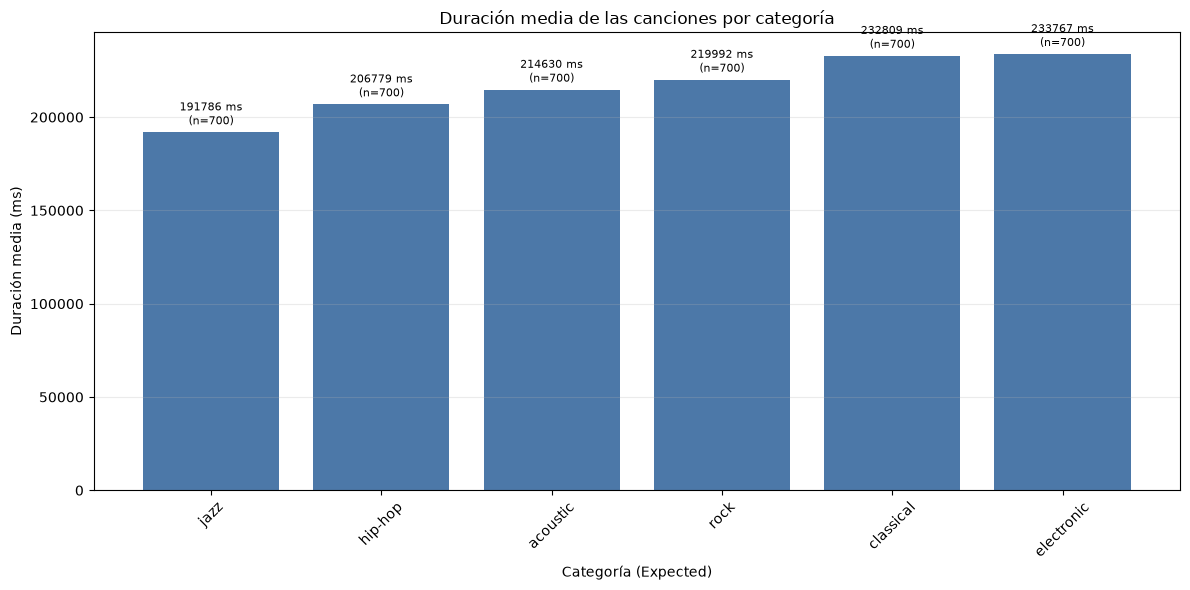

In [45]:
# Duración media de las canciones por categoría
resumen_duracion = (
    train.groupby("Expected")
    .agg(duracion_media_ms=("duration_ms", "mean"), cantidad_canciones=("duration_ms", "size"))
    .sort_values("duracion_media_ms")
)

fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(
    resumen_duracion.index,
    resumen_duracion["duracion_media_ms"],
    color="#4c78a8",
)

for barra, (_, fila) in zip(barras, resumen_duracion.iterrows()):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + resumen_duracion["duracion_media_ms"].max() * 0.01,
        f"{fila['duracion_media_ms']:.0f} ms\n(n={int(fila['cantidad_canciones'])})",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.set_title("Duración media de las canciones por categoría")
ax.set_xlabel("Categoría (Expected)")
ax.set_ylabel("Duración media (ms)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


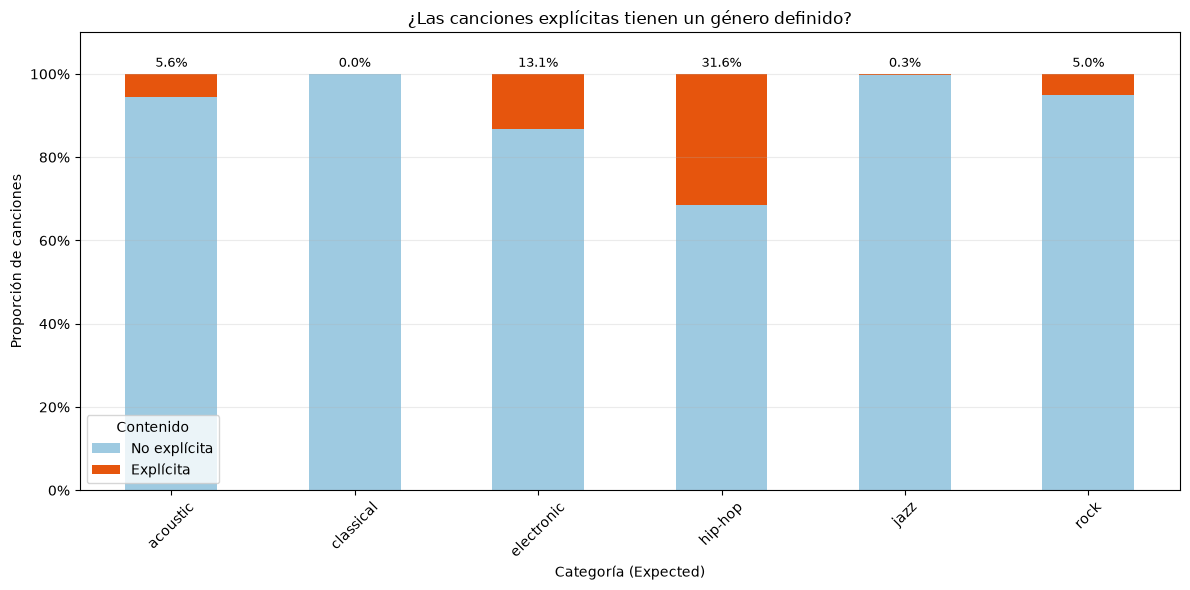

In [46]:
# Proporción de canciones explícitas y no explícitas por categoría
proporcion_explicit = pd.crosstab(
    train["Expected"],
    train["explicit"],
    normalize="index",
).reindex(columns=[False, True], fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
proporcion_explicit.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#9ecae1", "#e6550d"],
)

for posicion, (_, fila) in enumerate(proporcion_explicit.iterrows()):
    porcentaje_explicito = fila[True]
    ax.text(
        posicion,
        1.01,
        f"{porcentaje_explicito:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_title("¿Las canciones explícitas tienen un género definido?")
ax.set_xlabel("Categoría (Expected)")
ax.set_ylabel("Proporción de canciones")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda valor, posicion: f"{valor:.0%}"))
ax.legend(["No explícita", "Explícita"], title="Contenido")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


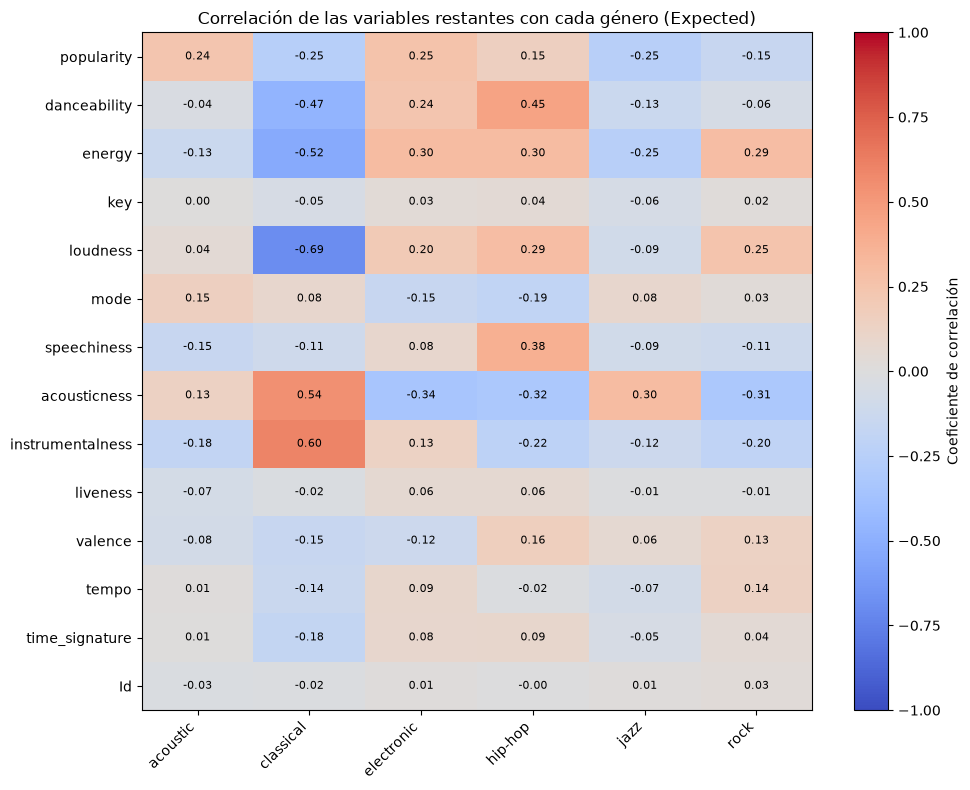

In [47]:
# Correlación de las variables restantes con cada género de Expected
variables = train.drop(columns=["Expected", "explicit", "duration_ms"]).select_dtypes(
    include=["number", "bool"]
).copy()
generos = pd.get_dummies(train["Expected"], dtype=int)

correlaciones_genero = pd.DataFrame({
    genero: variables.corrwith(generos[genero])
    for genero in generos.columns
})

fig, ax = plt.subplots(figsize=(10, 8))
imagen = ax.imshow(correlaciones_genero, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(correlaciones_genero.columns)))
ax.set_yticks(range(len(correlaciones_genero.index)))
ax.set_xticklabels(correlaciones_genero.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones_genero.index)
ax.set_title("Correlación de las variables restantes con cada género (Expected)")

for fila in range(len(correlaciones_genero.index)):
    for columna in range(len(correlaciones_genero.columns)):
        ax.text(
            columna,
            fila,
            f"{correlaciones_genero.iloc[fila, columna]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

fig.colorbar(imagen, ax=ax, label="Coeficiente de correlación")
plt.tight_layout()
plt.show()


> _Conclusiones:_

> En el primer grafico comparamos los generos con la duracion de las canciones promedio y vemos que en lineas generales no varia tanto, la unica que esta un poco por debajo es jazz, mientras que las que más duration tienen son electronica y clasica.

> En el segundo grafico, podemos encontrar la primer gran diferencia entre los generos, comparamos el porcentaje de las canciones que tenian palabras explicitas y concluimos que hiphop es la que más canciones tiene con palabras inapropiadas (gran diferencia). Seguido, por electronica. Despues, los generos jazz y clasica no tienen palabras explicitas en casi ninguna canción.

> En el ultimo grafico vemos que las variables key y liveness no tienen mucha correlación con ningun genero a predecir por lo que las vamos a borrar del dataset. Por decisión de modelado. Las borramos de train y de test para no generar fallas silenciosas.

> _Aclaración: Las visualizaciones estan basadas puramente en el csv de train (NO DATA LEAKAGE)._

In [48]:
train = train.drop( columns = ["liveness"])
train = train.drop( columns = ["key"])
test = test.drop( columns = ["liveness"])
test = test.drop( columns = ["key"])

## 3. Preprocesamiento y preparación del conjunto de modelado

Separar la variable objetivo `Expected` y excluir `Id` de las variables predictoras. Definir una estrategia reproducible para dividir el conjunto de entrenamiento en entrenamiento y validación estratificada.

Evaluar qué preprocesamiento corresponde aplicar: tratamiento de valores faltantes si aparecieran, escalado de variables numéricas, codificación de variables booleanas o categóricas y tratamiento de valores atípicos si el análisis exploratorio lo justifica. Usar un `Pipeline` o una estructura equivalente para que las transformaciones se ajusten solamente sobre el subconjunto de entrenamiento.

**Pregunta que buscamos responder:** ¿Qué transformaciones necesitan los datos para que los modelos aprendan correctamente sin introducir fuga de información?

In [49]:
# Separar Expected y excluir Id de las predictorias. Para despues entregar en Kaggle.

# acá SÍ tenemos la respuesta correcta
y_train = train["Expected"]
X_train = train.drop(columns=["Expected", "Id"])

# acá NO tenemos la respuesta, hay que predecirla
# Guardamos el Id aparte porque lo vamos a necesitar para el archivo de entrega
test_ids = test["Id"]
X_test = test.drop(columns=["Id"])

> Del análisis del punto 1, no tenemos valores faltantes en ningun dataset.

> Como vamos a utlilizar modelos con arboles de decisiones no vamos a escalar datos numericos.

> Tampoco vamos a modificar variables booleanas por la misma razón.

> Vamos a convertir la variable categórica Expected a numérica usando Label Encoder para poder trabajar con algoritmos de árboles de decisión. Esto no genera sesgo de distancia, porque Expected es la variable a predecir (target) y no una feature. El algoritmo de clasificación no realiza operaciones como restas, distancias entre los valores del target, sino que los trata como etiquetas de clase independientes. 

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train["Expected"])

Para subdividir el conjunto de train en: train + validación, vamos a utilizar un método llamado K-fold Cross-Validation (utilizado en el anterior trabajo practico). 

Lo que haremos es:
> Dividir en K-Folds el dataset de train.
> En cada iteración, utilizar un distinto fold para hacer validación.
> De esta manera, eliminaremos la probabilidad de que la validación del entrenamiento sea sesgada por un fold fijo.
> Dividimos en 5 folds (elección de número arbitraria).

In [51]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4. Implementación de modelos

Implementar al menos dos modelos de Machine Learning distintos para clasificación multiclase. Conviene elegir modelos con supuestos y comportamientos diferentes, por ejemplo un modelo lineal como `LogisticRegression` y un modelo basado en árboles como `RandomForestClassifier` o `HistGradientBoostingClassifier`.

Entrenar ambos modelos con el mismo esquema de división o validación cruzada estratificada. Mantener fijos los datos de evaluación y las métricas para que la comparación sea justa.

**Pregunta que buscamos responder:** ¿Un modelo lineal alcanza para separar los géneros o un modelo no lineal captura mejor las relaciones entre las métricas acústicas?

**Conclusión esperada:** reportar los modelos utilizados, sus principales hiperparámetros y una primera comparación de resultados, sin seleccionar un modelo únicamente por intuición.

Vamos a utilizar dos algoritmos para entrenar el modelo.

> 1) RandomForestClassifier: Algoritmo de Bagging --> Arma muchos árboles y predice con el promedio mayoritario.

> 2) HistGradientBoostingClassifier: Algoritmo de Boosting --> Arma muchos árboles y se esperan para corregirse los errores.

In [52]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

modelo_bagging = RandomForestClassifier(random_state=42)
modelo_boosting = HistGradientBoostingClassifier(random_state=42)

scores_bagging = cross_val_score(modelo_bagging, X_train, y_train, cv=skf, scoring="f1_macro")
scores_boosting = cross_val_score(modelo_boosting, X_train, y_train, cv=skf, scoring="f1_macro")

print("Bagging (Random Forest) - F1 macro:", scores_bagging.mean(), "+/-", scores_bagging.std())
print("Boosting (HistGradientBoosting) - F1 macro:", scores_boosting.mean(), "+/-", scores_boosting.std())


Bagging (Random Forest) - F1 macro: 0.8217965587366812 +/- 0.01023702868423455
Boosting (HistGradientBoosting) - F1 macro: 0.8343155275507523 +/- 0.006263810385794482


> Los resultados para ambos algoritmos son de ≈ 0.82.. No vemos diferencia muy grande entre los dos algoritmos.

> Ahora, vamos a ver como nos va con la métrica **MAP@3**. 

> _Se mide por:_

> 1) Si acertó en el primer lugar → 1 punto (perfecto).

> 2) Si la respuesta correcta apareció en el segundo lugar → 1/2 punto.

> 3) Si apareció en el tercer lugar → 1/3 punto.

> 4) Si ni entre las 3 primeras adivinó → 0 puntos.

In [53]:
# MAP@3 en Random Forest.

resultados_map3 = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    modelo = RandomForestClassifier(random_state=42)
    modelo.fit(X_fold_train, y_fold_train)

    y_proba = modelo.predict_proba(X_fold_val)
    resultados_map3.append(mapk3(y_fold_val, y_proba, modelo.classes_))

print("MAP@3 por fold:", resultados_map3)
print("MAP@3 promedio:", np.mean(resultados_map3))


MAP@3 por fold: [np.float64(0.8773809523809524), np.float64(0.8926587301587301), np.float64(0.8942460317460318), np.float64(0.8938492063492064), np.float64(0.88015873015873)]
MAP@3 promedio: 0.8876587301587302


In [54]:
# MAP@3 en HistGradientBoostingClassifier.

resultados_map3 = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    modelo = HistGradientBoostingClassifier(random_state=42)
    modelo.fit(X_fold_train, y_fold_train)

    y_proba = modelo.predict_proba(X_fold_val)
    resultados_map3.append(mapk3(y_fold_val, y_proba, modelo.classes_))

print("MAP@3 por fold:", resultados_map3)
print("MAP@3 promedio:", np.mean(resultados_map3))

MAP@3 por fold: [np.float64(0.8936507936507937), np.float64(0.8992063492063491), np.float64(0.9027777777777777), np.float64(0.8994047619047619), np.float64(0.8902777777777778)]
MAP@3 promedio: 0.897063492063492


> Con las métricas de F1-Score (Macro) y MAP@3 nos dio mejores resultados el algoritmo de Boosting. Entonces, en el proximo punto vamos a seguir probando más algoritmos de este estilo.

> Vamos a probar más algoritmos de boosting para ver cual da los mejores resultados.

In [61]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score

modelos_boosting_v2 = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
}

for nombre, modelo in modelos_boosting_v2.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=skf, scoring="f1_macro")
    print(f"{nombre} - F1 macro: {scores.mean():.4f} +/- {scores.std():.4f}")


XGBoost - F1 macro: 0.8262 +/- 0.0071
LightGBM - F1 macro: 0.8278 +/- 0.0050
CatBoost - F1 macro: 0.8291 +/- 0.0104


> Probamos nuevos algoritmos de Boosting:

- **XGBoost**: Gradient Boosting optimizado con regularización para reducir sobreajuste; rinde mejor si se ajustan bien sus hiperparámetros.
- **LightGBM**: Crece los árboles hoja por hoja (no nivel por nivel), lo que lo hace más rápido pero más propenso a sobreajustar en datasets chicos.
- **CatBoost**: Maneja variables categóricas de forma nativa y suele ser más estable con hiperparámetros por defecto.

| Modelo | F1-macro (CV local) | Score Kaggle |
|---|---|---|
| HistGradientBoosting | ≈ 0.83 | 0.83310 |
| CatBoost | 0.8291 ± 0.0104 | 0.83287 |
| LightGBM | 0.8278 ± 0.0050 | — |
| XGBoost | 0.8262 ± 0.0071 | 0.82387 |


## 5. Evaluación y comparación de resultados

Evaluar los modelos sobre el conjunto de validación utilizando accuracy y macro-F1. La accuracy indica el porcentaje total de predicciones correctas, mientras que macro-F1 asigna el mismo peso a cada género y permite detectar si el modelo funciona mal en alguna clase minoritaria.

También, buscaremos hiperparametros para buscar personalizar los algoritmos de boosting para que den los mejores resultados.

Complementar las métricas con una matriz de confusión y un classification report por género. Si se utiliza validación cruzada, informar la media y la dispersión de las métricas, no solamente el mejor resultado.

**Pregunta que buscamos responder:** ¿Qué modelo generaliza mejor y qué géneros se confunden entre sí?

**Conclusión esperada:** seleccionar el modelo final con evidencia, explicando el balance entre desempeño global, desempeño por clase, estabilidad y complejidad.

> Especificamente, vamos a optimizar los algoritmos de HistGradientBoosting y CatBoost. Que fue lo que mejor resultados dio.

> Busquemos los mejores hiperparametros con RandomSearchCV:
>> Probamos 30 iteraciones con parametros random. Después, analizamos que combinaciones dieron mejor.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

#  HistGradientBoosting - Busqueda random de hiperparametros.
parametros_hist = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_iter": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, None],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [10, 20, 30],
    "l2_regularization": [0, 0.1, 1, 5],
}

busqueda_hist = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=42),
    param_distributions=parametros_hist,
    n_iter=30,
    scoring="f1_macro",
    cv=skf,
    random_state=42,
    n_jobs=-1,
)
busqueda_hist.fit(X_train, y_train)

print("Mejores parámetros (HistGradientBoosting):", busqueda_hist.best_params_)
print("Mejor F1 macro (HistGradientBoosting):", busqueda_hist.best_score_)


Mejores parámetros (HistGradientBoosting): {'min_samples_leaf': 10, 'max_leaf_nodes': 15, 'max_iter': 300, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 1}
Mejor F1 macro (HistGradientBoosting): 0.8336012376623063


In [68]:
# --- CatBoost ---
parametros_catboost = {
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [200, 300, 400],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1, 3, 5],
}

busqueda_catboost = RandomizedSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=0, thread_count=-1),
    param_distributions=parametros_catboost,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=1,
)
busqueda_catboost.fit(X_train, y_train)

print("Mejores parámetros (CatBoost):", busqueda_catboost.best_params_)
print("Mejor F1 macro (CatBoost):", busqueda_catboost.best_score_)



Mejores parámetros (CatBoost): {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 8}
Mejor F1 macro (CatBoost): 0.8126331388555258


> Ahora, veamos en visualizaciones que obtuvimos en la RandomSearchCV.

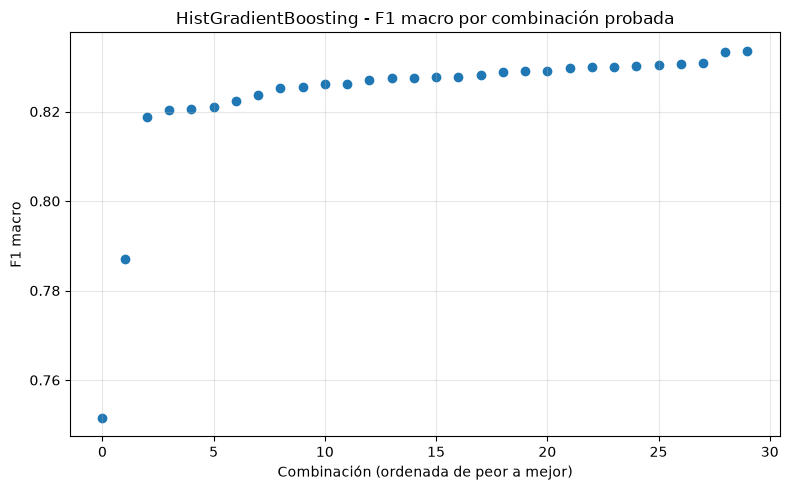

In [70]:
resultados_hist = pd.DataFrame(busqueda_hist.cv_results_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(range(len(resultados_hist)), resultados_hist["mean_test_score"].sort_values())
ax.set_title("HistGradientBoosting - F1 macro por combinación probada")
ax.set_xlabel("Combinación (ordenada de peor a mejor)")
ax.set_ylabel("F1 macro")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

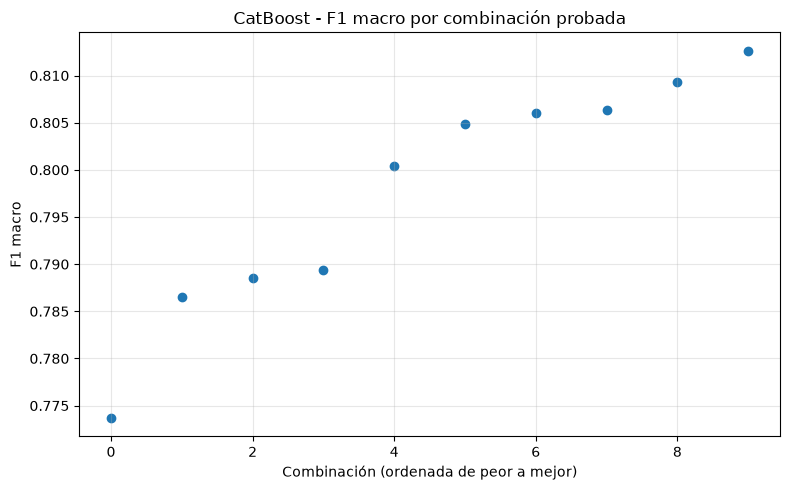

In [71]:
resultados_catboost = pd.DataFrame(busqueda_catboost.cv_results_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(range(len(resultados_catboost)), resultados_catboost["mean_test_score"].sort_values())
ax.set_title("CatBoost - F1 macro por combinación probada")
ax.set_xlabel("Combinación (ordenada de peor a mejor)")
ax.set_ylabel("F1 macro")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> Vemos que a más combinaciones probadas, mejores resultados de F1-Score vemos.

In [73]:
tabla_hiperparametros = pd.DataFrame([
    {"Modelo": "HistGradientBoosting", "F1 macro": busqueda_hist.best_score_, **busqueda_hist.best_params_},
    {"Modelo": "CatBoost", "F1 macro": busqueda_catboost.best_score_, **busqueda_catboost.best_params_},
])

tabla_hiperparametros

,Modelo,F1 macro,min_samples_leaf,max_leaf_nodes,max_iter,max_depth,learning_rate,l2_regularization,l2_leaf_reg,iterations,depth
0,HistGradientBoosting,0.833601,10.0,15.0,300.0,NaN,0.05,1.0,NaN,NaN,NaN
1,CatBoost,0.812633,NaN,NaN,NaN,NaN,0.05,NaN,5.0,300.0,8.0


> Ahora, con los mejores parametros encontrados corremos devuelta los algoritmos para ver si mejoraron un poco las métrica.

In [74]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

modelo_hist_final = HistGradientBoostingClassifier(random_state=42, **busqueda_hist.best_params_)
modelo_catboost_final = CatBoostClassifier(random_state=42, verbose=0, **busqueda_catboost.best_params_)

modelos_finales = {
    "HistGradientBoosting": modelo_hist_final,
    "CatBoost": modelo_catboost_final,
}

for nombre, modelo in modelos_finales.items():
    acc = cross_val_score(modelo, X_train, y_train, cv=skf, scoring="accuracy")
    f1 = cross_val_score(modelo, X_train, y_train, cv=skf, scoring="f1_macro")
    print(f"{nombre}")
    print(f"  Accuracy: {acc.mean():.4f} +/- {acc.std():.4f}")
    print(f"  F1 macro: {f1.mean():.4f} +/- {f1.std():.4f}")


HistGradientBoosting
  Accuracy: 0.8336 +/- 0.0090
  F1 macro: 0.8336 +/- 0.0092
CatBoost
  Accuracy: 0.8188 +/- 0.0112
  F1 macro: 0.8186 +/- 0.0112


--- HistGradientBoosting ---
              precision    recall  f1-score   support

    acoustic       0.77      0.80      0.78       700
   classical       0.90      0.88      0.89       700
  electronic       0.80      0.80      0.80       700
     hip-hop       0.85      0.90      0.87       700
        jazz       0.82      0.77      0.80       700
        rock       0.86      0.85      0.86       700

    accuracy                           0.83      4200
   macro avg       0.83      0.83      0.83      4200
weighted avg       0.83      0.83      0.83      4200

--- CatBoost ---
              precision    recall  f1-score   support

    acoustic       0.74      0.80      0.76       700
   classical       0.90      0.88      0.89       700
  electronic       0.78      0.80      0.79       700
     hip-hop       0.84      0.89      0.87       700
        jazz       0.81      0.71      0.76       700
        rock       0.85      0.84      0.84       700

    accuracy                   

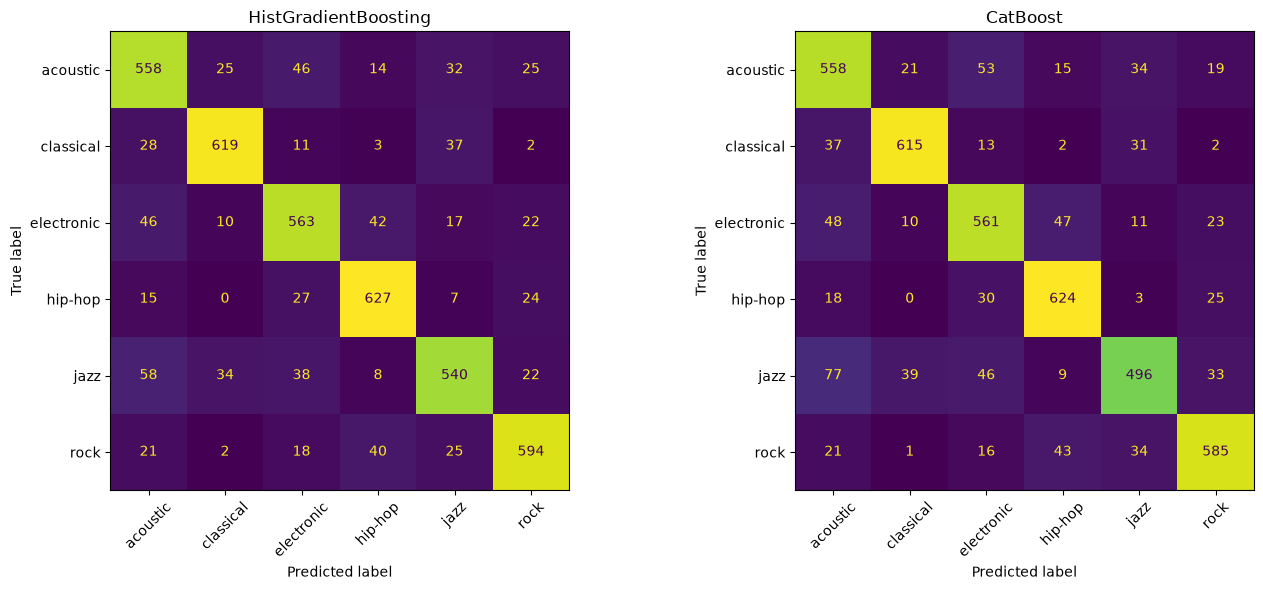

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nombre, modelo) in zip(axes, modelos_finales.items()):
    predicciones_cv = cross_val_predict(modelo, X_train, y_train, cv=skf)

    print(f"--- {nombre} ---")
    print(classification_report(y_train, predicciones_cv, target_names=le.classes_))

    ConfusionMatrixDisplay.from_predictions(
        y_train, predicciones_cv,
        display_labels=le.classes_,
        xticks_rotation=45,
        ax=ax,
        colorbar=False,
    )
    ax.set_title(nombre)

plt.tight_layout()
plt.show()


> Viendo la matriz de confusión entre generos, tenemos margen de mejora.

> Nos gustaria no tener más de 20 en confusiones.

>> Analizaremos como podemos mejorarlo.

> Habiendo entregado en kaggle nuestro modelo parametrizado de HGB no dio mejores resultados que el primer HGB. 
>> Por lo tanto, vamos a implementar un modelo ensamblado. (HGB + CatBoost)

In [83]:
from sklearn.ensemble import VotingClassifier

modelo_hgb = HistGradientBoostingClassifier(random_state=42)
modelo_cat = CatBoostClassifier(random_state=42, verbose=0)

ensemble = VotingClassifier(
    estimators=[("hgb", modelo_hgb), ("catboost", modelo_cat)],
    voting="soft",
)

scores_ensemble = cross_val_score(ensemble, X_train, y_train, cv=skf, scoring="f1_macro")
print("Ensemble (HGB + CatBoost) - F1 macro:", scores_ensemble.mean(), "+/-", scores_ensemble.std())


Ensemble (HGB + CatBoost) - F1 macro: 0.8394781411754761 +/- 0.008243748961876345


> Entregando en kaggle, el modelo no mejoro practicamente nada. 

> Podemos concluir que como son ambos algoritmos de árboles, no hay oportunidad de mejor ya que deciden de la misma manera.

>> Ahora nos queda probar las siguientes opciones para intentar mejorar el modelo:
>> 1) Implementar en el modelo ensamblado un modelos lineal que decida distinto de los árboles.
>> 2) Intentar separar features para mejorar predicciones de expected como: acousticness, instrumentalness y energy.
>> 3) Fijarse si no hay mejora con incluir las features que dejamos afuera "liveness" y "key".

## 6. Entrenamiento final y archivo de submission

Una vez seleccionado el modelo, reentrenarlo utilizando todos los registros etiquetados de `train.csv`. Luego predecir la columna `Expected` para cada fila de `test.csv` y construir el archivo de submission con las columnas y el formato exigidos por la competencia, conservando los valores de `Id` sin modificarlos.

Verificar antes de exportar que el archivo tenga exactamente una predicción por fila de test, que no haya valores nulos y que las clases predichas pertenezcan al conjunto esperado. Guardar el resultado como CSV y, si corresponde, registrar el score obtenido en Kaggle.

**Pregunta que buscamos responder:** ¿Cómo se traduce el modelo validado en una entrega reproducible para datos no etiquetados?

**Conclusión esperada:** dejar documentado el modelo final, la métrica local y el score de Kaggle, aclarando cualquier diferencia entre ambos resultados.

## 7. Conclusiones del análisis

Resumir los hallazgos principales del EDA, las decisiones de preprocesamiento y la comparación de modelos. Indicar qué variables fueron más informativas según la evidencia disponible y qué géneros resultaron más fáciles o difíciles de clasificar.

Comparar el desempeño local con el resultado de Kaggle y discutir posibles causas de diferencias, como la composición del conjunto de test, la variabilidad del muestreo o el sobreajuste al conjunto de validación.

**Pregunta que buscamos responder:** ¿Qué aprendimos sobre la relación entre las características acústicas y el género musical, más allá del score de la competencia?

**Conclusión esperada:** presentar una respuesta crítica y respaldada por métricas, visualizaciones y observaciones del comportamiento del modelo.

## Bonus point. Interpretabilidad y análisis de errores

Analizar por qué el modelo se equivoca y qué variables influyen en sus decisiones. Utilizar herramientas acordes al modelo, como importancia de variables, coeficientes, permutation importance o SHAP si está disponible en el entorno. Relacionar estos resultados con la matriz de confusión y estudiar algunos ejemplos representativos de cada confusión frecuente.

También se puede comparar el comportamiento del modelo entre géneros y evaluar si la confianza de las predicciones cambia según la clase. No se busca solamente mejorar el score, sino entender cuándo el modelo es confiable y qué información adicional podría ayudarlo.

**Pregunta de investigación adicional:** ¿Las variables más importantes para el modelo coinciden con las diferencias observadas en el EDA y con una interpretación musical razonable?

**Valor agregado:** este análisis conecta el rendimiento estadístico con una explicación del fenómeno musical. Puede revelar sesgos del dataset, variables redundantes o géneros que necesitan más datos, y permite justificar mejor la elección del modelo final.

In [84]:
ensemble.fit(X_train, y_train)

predicciones = ensemble.predict(X_test)
predicciones_generos = le.inverse_transform(predicciones)

submission = pd.DataFrame({
    "Id": test_ids,
    "Expected": predicciones_generos
})
submission.to_csv("submission_ensemble_hgb_cat.csv", index=False)
